In [ ]:
# 6.2. Untersuchung von Zusammenhängen

## 1. Import Biblioteks

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

## 2. Import data

In [58]:
base_path = r'C:\Users\faink\Desktop\Achievement_6\02_data'
cleaned_path = os.path.join(base_path, "2_cleaned")
path_plot = r"C:\Users\faink\Desktop\Achievement_6\05_visual"

df = pd.read_csv(os.path.join(cleaned_path, "cleaned_data.csv"))

## 3. Überblick über die Daten

In [52]:
df.describe()

,happiness_final,gdp_final,social_support,health_final,freedom_final,generosity,corruption_final
count,1084.000000,1084.000000,614.000000,1084.000000,1084.000000,1084.000000,1083.000000
mean,5.413460,3.269365,1.014611,18.471404,0.515936,0.153545,0.294111
std,1.118595,3.854953,0.304179,28.981743,0.221478,0.167592,0.300707
min,2.523000,0.000000,0.000000,0.000000,0.000000,-0.300907,0.000000
25%,4.571000,0.780500,0.810250,0.552500,0.366947,0.064828,0.068178
50%,5.385150,1.170350,0.922247,0.773948,0.502269,0.162140,0.136957
75%,6.216125,7.640969,1.268750,54.707750,0.658436,0.252000,0.500726
max,7.842000,11.647000,1.644000,76.953000,0.974998,0.838075,0.939000


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country_final     1231 non-null   object 
 1   region_final      617 non-null    object 
 2   happiness_final   1084 non-null   float64
 3   gdp_final         1084 non-null   float64
 4   social_support    614 non-null    float64
 5   health_final      1084 non-null   float64
 6   freedom_final     1084 non-null   float64
 7   generosity        1084 non-null   float64
 8   corruption_final  1083 non-null   float64
dtypes: float64(7), object(2)
memory usage: 86.7+ KB


In [54]:
# Zeilen und Spalten
print("Form des Datensatzes:", df.shape)

# Erste Zeilen anzeigen
df.head()

# Statistische Übersicht
df.describe(include="all")

# Anzahl fehlender Werte
df.isna().sum()


Form des Datensatzes: (1231, 9)


country_final         0
region_final        614
happiness_final     147
gdp_final           147
social_support      617
health_final        147
freedom_final       147
generosity          147
corruption_final    148
dtype: int64

## 4. Korrelationsmatrix

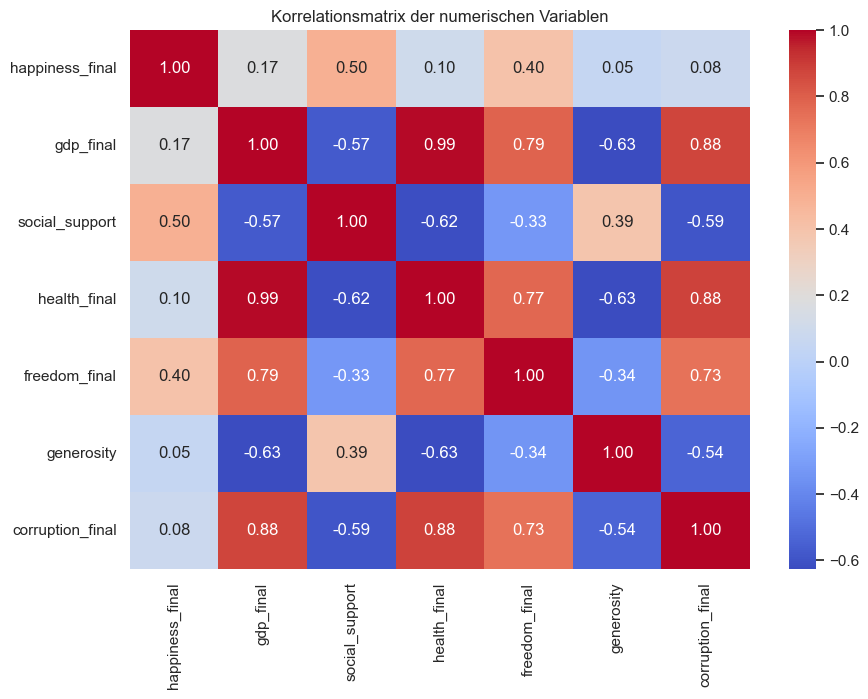

<Figure size 640x480 with 0 Axes>

In [59]:
# Nur numerische Variablen auswählen
numeric_cols = [
    "happiness_final",
    "gdp_final",
    "social_support",
    "health_final",
    "freedom_final",
    "generosity",
    "corruption_final"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korrelationsmatrix der numerischen Variablen")
plt.show()

plt.savefig(os.path.join(path_plot, "korrelationsmatrix.png"), dpi=300, bbox_inches="tight")

## 5. Histogramme für jede numerische Variabl

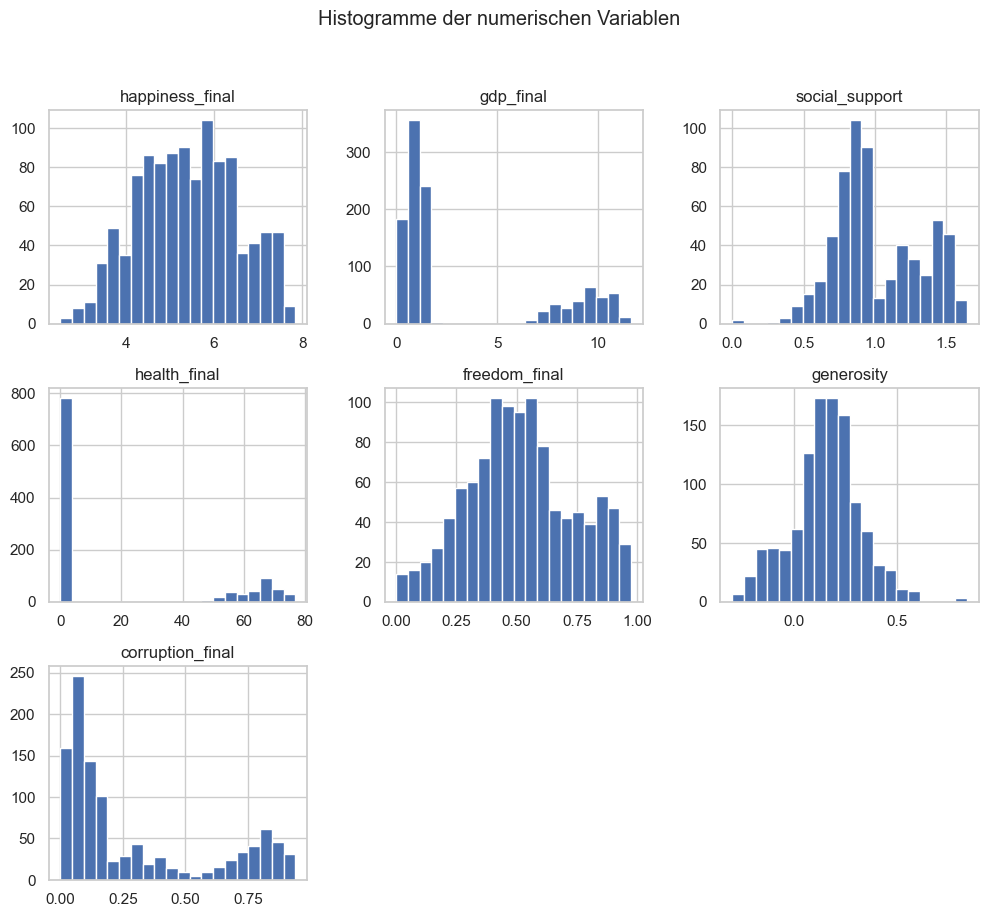

<Figure size 640x480 with 0 Axes>

In [60]:
df[numeric_cols].hist(figsize=(12, 10), bins=20)
plt.suptitle("Histogramme der numerischen Variablen")
plt.show()

plt.savefig(os.path.join(path_plot, "histogramme.png"), dpi=300, bbox_inches="tight")

## 6. Scatterplots: Beziehung zum Happiness Score

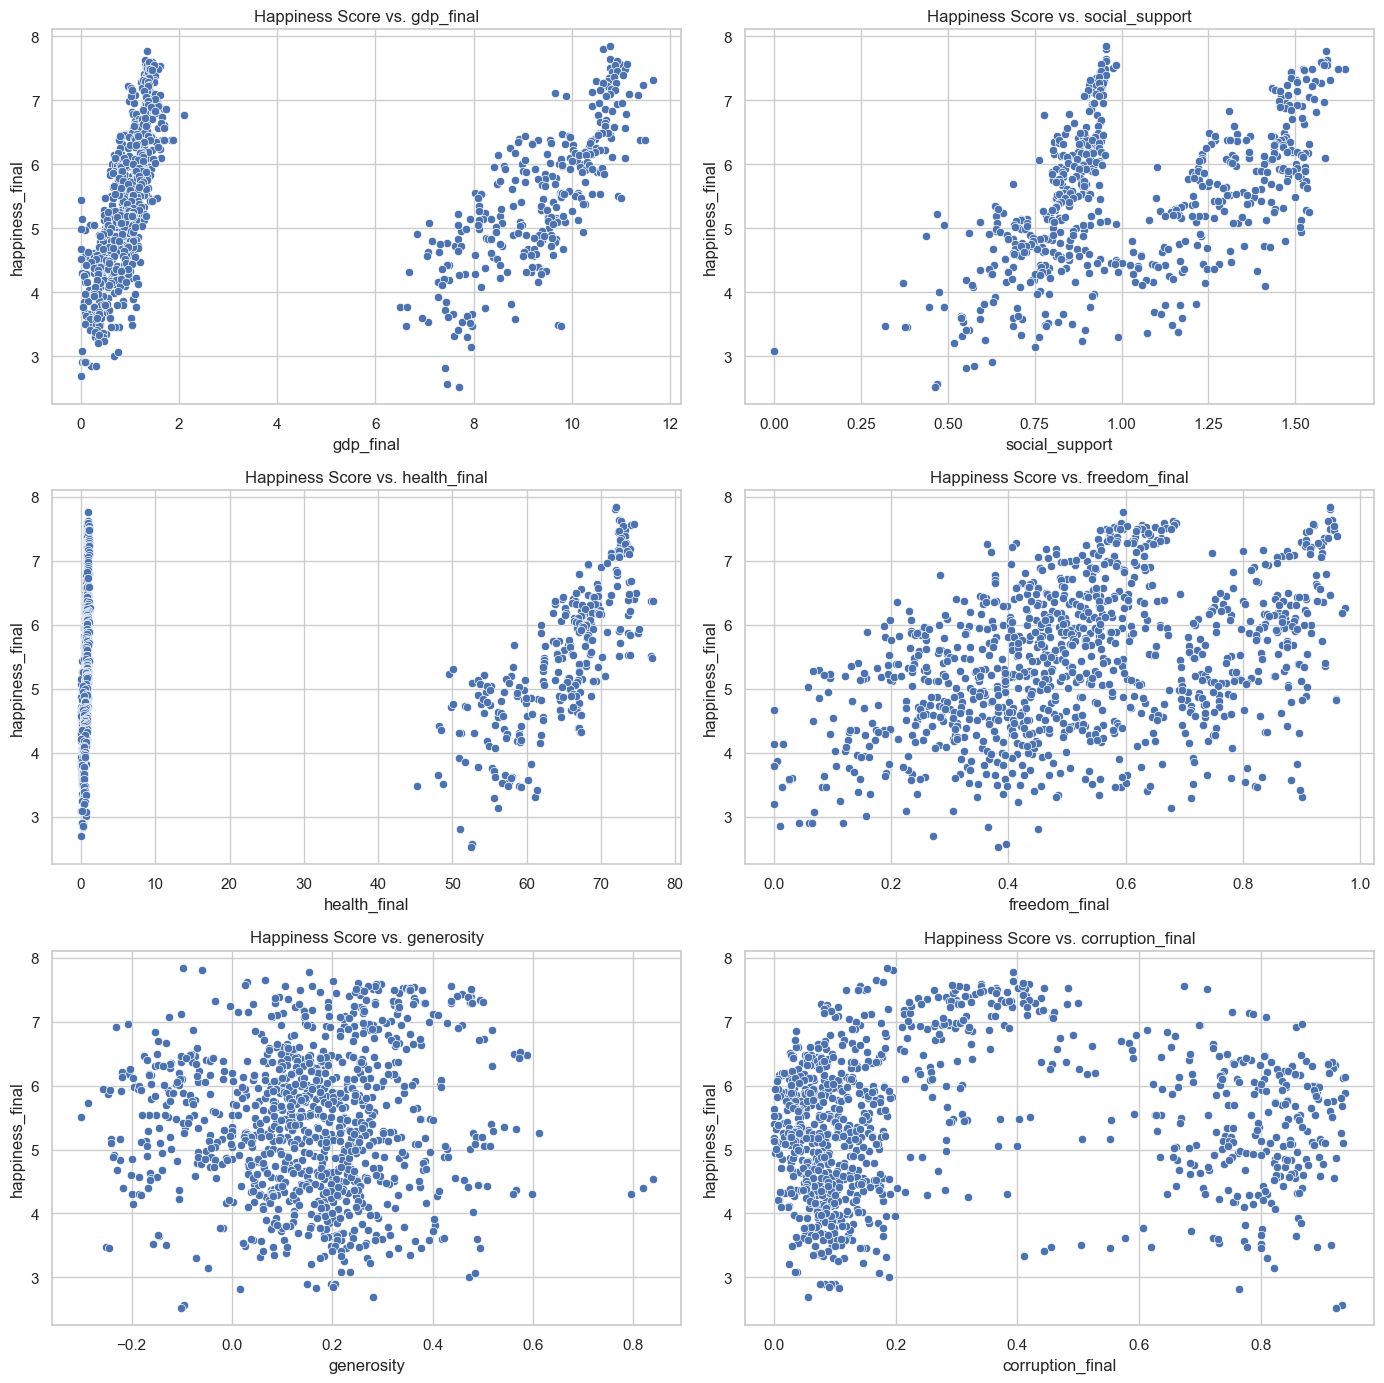

<Figure size 640x480 with 0 Axes>

In [61]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[1:]):  # ohne happiness_final
    sns.scatterplot(data=df, x=col, y="happiness_final", ax=axes[i])
    axes[i].set_title(f"Happiness Score vs. {col}")

plt.tight_layout()
plt.show()

plt.savefig(os.path.join(path_plot, "scatterplots_happiness.png"), dpi=300, bbox_inches="tight")

## 7. Gruppenvergleich nach Region

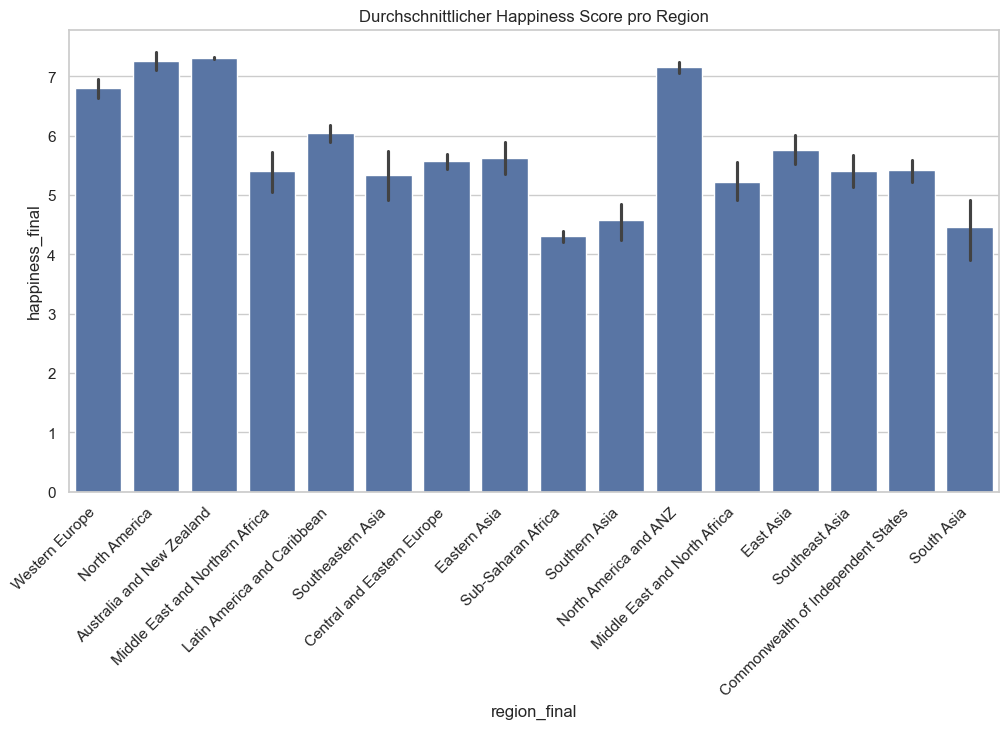

<Figure size 640x480 with 0 Axes>

In [62]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="region_final", y="happiness_final", estimator="mean")
plt.xticks(rotation=45, ha="right")
plt.title("Durchschnittlicher Happiness Score pro Region")
plt.show()

plt.savefig(os.path.join(path_plot, "happiness_region.png"), dpi=300, bbox_inches="tight")

Alle Visualisierungen werden zusätzlich als PNG‑Dateien im Ordner
05_visual gespeichert. Dafür wird plt.savefig() mit dem definierten
Pfad path_plot verwendet. Die Option bbox_inches="tight" stellt sicher,
dass die Grafiken ohne abgeschnittene Achsen gespeichert werden.